### Imports

In [1]:
import os
import random
import torch
import matplotlib.pyplot as plt
import pandas as pd

seed = 42
random.seed(seed)

## Exploratory Data Analysis

We will take a random subset of the data, and do some analysis on it.

In [2]:
path = "../data/dataset"
n = 100
files = random.sample(os.listdir(path), n)

Lets start by printing some examples

In [3]:
for file in files[:5]:
    sample = torch.load(os.path.join(path, file))

    print(file)
    print(sample["frames"].shape)
    print(sample["person"])
    print(sample["age"])
    print()

pos_018952.pt
torch.Size([8, 3, 224, 224])
1
54

pos_001648.pt
torch.Size([8, 3, 224, 224])
1
1

neg_000819.pt
torch.Size([8, 3, 224, 224])
0
-1

pos_022299.pt
torch.Size([8, 3, 224, 224])
1
75

pos_007012.pt
torch.Size([8, 3, 224, 224])
1
26



Lets also look at some of the images

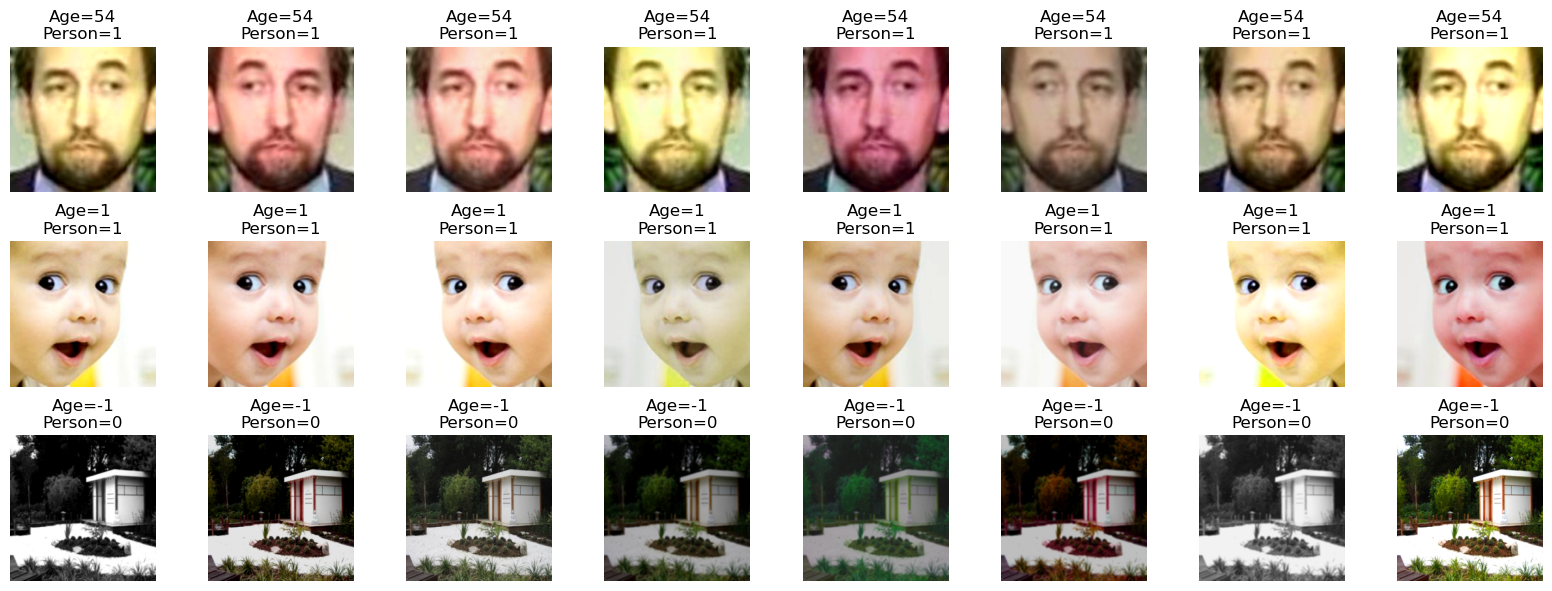

In [11]:
show_samples = 3

fig, axes = plt.subplots(
    nrows=show_samples,
    ncols=8,
    figsize=(16, 2 * show_samples)
)

for row, file in enumerate(files[:show_samples]):
    sample = torch.load(os.path.join(path, file))
    frames = sample["frames"]
    
    for col in range(frames.shape[0]):
        # get the frame and permute so the rgb channel is at the end
        img = frames[col].permute(1, 2, 0)

        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        axes[row, col].set_title(
                f'Age={sample["age"]}\nPerson={sample["person"]}'
            )

plt.tight_layout()
plt.show()

Now we construct a dataframe to do further analysis on pandas

In [4]:
records = []

for file in files:
    sample = torch.load(os.path.join(path, file))

    records.append({
        "file": file,
        "person": sample["person"],
        "age": sample["age"]
    })

df = pd.DataFrame(records)
df.describe()

,person,age
count,100.000000,100.000000
mean,0.930000,30.860000
std,0.256432,21.803076
min,0.000000,-1.000000
25%,1.000000,17.000000
50%,1.000000,26.000000
75%,1.000000,45.750000
max,1.000000,85.000000


In [ ]:
# person vs non-person
df["person"].value_counts()

person
1    93
0     7
Name: count, dtype: int64

Lets look at the age distribution of our sample

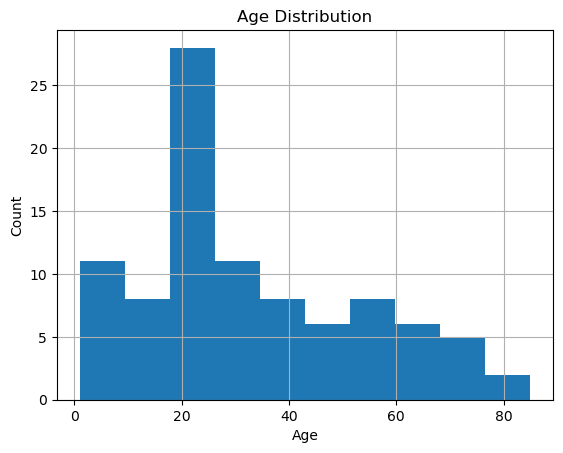

In [9]:
df[df["person"] == 1]["age"].hist(bins=10)

plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.show()

We observe that the dataset is heavily dominated by images of people, since only 2,000 non-person samples were included during dataset construction. This imbalance may have some impact on model performance, although we expect it to be limited. Additionally, within a subset of 100 samples, we notice a clear overrepresentation of young adults, indicating a potential age distribution bias in the data.